# Streamlined Sensitivity Analysis: Cinema Showtime Optimization

**Updated to match main optimization formulation with LINEAR repetition penalty**

This notebook focuses on the **key parameters with non-obvious, interesting effects**:
1. **Ticket Price** - Finding optimal pricing with demand elasticity (ε = 1.2)
2. **Repetition Penalty** - LINEAR penalty balancing revenue vs intra-day variety
3. **Max Showings Per Movie** - Hard constraint on repetition (hard vs soft)
4. **Demand Variations** - Understanding capacity constraints and scalability
5. **Minimum Genres** - Hard constraint ensuring programming diversity

**Key Formulation Details:**
- Price elasticity: Adjusted Demand = Base Demand × (Base Price / Current Price)^1.2
- Linear repetition penalty: Penalty = Cost × (Total Showings - Scheduled Movie-Days)
- Genre diversity: Minimum constraint only (no bonus in objective)

In [89]:
import gurobipy as gp
from gurobipy import GRB
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## Load Baseline Data and Setup

Import model creation function and baseline results from your main optimization notebook.

In [103]:
# Key parameters to test - UPDATED to match main optimization formulation
BASE_TICKET_PRICE = 11.31  # Reference price for elasticity
PRICE_ELASTICITY = 1.2  # Demand decreases by 1.2% for every 1% price increase
MIN_GENRES = 5  # Minimum genres required per day
REPETITION_PENALTY_PER_SHOWING = 50  # Linear penalty: $ per showing beyond first per day

In [104]:
# Load baseline results
results_dir = Path("results")

baseline_schedule = pd.read_csv(results_dir / "baseline_schedule.csv")
baseline_realized = pd.read_csv(results_dir / "baseline_realized.csv")
baseline_summary = pd.read_csv(results_dir / "baseline_summary.csv")
baseline_params = pd.read_csv(results_dir / "baseline_parameters.csv")
movie_data = pd.read_csv(results_dir / "movie_data.csv")
demand_data = pd.read_csv(results_dir / "demand_data.csv")

print("Baseline Results Loaded:")
print("="*60)
for _, row in baseline_summary.iterrows():
    print(f"{row['metric']}: {row['value']:,.2f}")

Baseline Results Loaded:
total_revenue: 320,998.10
total_showings: 121.00
total_tickets_sold: 28,510.00
num_movies_scheduled: 105.00
num_screens_used: 16.00
avg_showings_per_movie: 8.93
avg_tickets_per_showing: 212.76
capacity_utilization: 1.01


In [115]:
baseline_params

,parameter,value
0,ticket_price,11.31
1,buffer_min,15.00
2,max_showings_per_movie_per_day,6.00
3,num_screens,19.00
4,operating_hours_per_day,12.00
5,num_movies,15.00
6,num_days,7.00


## Setup: Import Model Creation Function

In [105]:
# Theater configuration
NUM_SCREENS = 19
SCREENS = [f"Screen_{i}" for i in range(1, NUM_SCREENS+1)]
SCREEN_CAPACITIES = {s: 210 for s in SCREENS[:19]}
SCREEN_CAPACITIES["Screen_19"] = 600

DAYS = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

# Get baseline parameters
def get_param(name):
    return baseline_params[baseline_params['parameter'] == name]['value'].values[0]

BASELINE_TICKET_PRICE = get_param('ticket_price')
BASELINE_BUFFER_MIN = int(get_param('buffer_min'))
BASELINE_MAX_SHOWINGS = int(get_param('max_showings_per_movie_per_day'))
BASELINE_OPERATING_HOURS = get_param('operating_hours_per_day')

# Model parameters (matching main optimization formulation)
BASE_TICKET_PRICE = BASELINE_TICKET_PRICE  # Reference price for elasticity calculations
PRICE_ELASTICITY = 1.2  # Demand decreases by 1.2% for every 1% price increase
MIN_GENRES = 5  # Minimum genres required per day
REPETITION_PENALTY_PER_SHOWING = 50  # Linear penalty: cost per showing beyond first per day

print(f"Baseline Parameters:")
print(f"  Ticket Price: ${BASELINE_TICKET_PRICE:.2f}")
print(f"  Buffer Time: {BASELINE_BUFFER_MIN:.0f} minutes")
print(f"  Max Showings/Movie/Day: {BASELINE_MAX_SHOWINGS}")
print(f"  Operating Hours: {BASELINE_OPERATING_HOURS:.1f} hours")
print(f"\nModel Parameters (from main formulation):")
print(f"  Price Elasticity: {PRICE_ELASTICITY}")
print(f"  Min Genres: {MIN_GENRES}")
print(f"  Repetition Penalty (LINEAR): ${REPETITION_PENALTY_PER_SHOWING} per showing beyond first")

Baseline Parameters:
  Ticket Price: $11.31
  Buffer Time: 15 minutes
  Max Showings/Movie/Day: 6
  Operating Hours: 12.0 hours

Model Parameters (from main formulation):
  Price Elasticity: 1.2
  Min Genres: 5
  Repetition Penalty (LINEAR): $50 per showing beyond first


In [106]:
# # Prepare data structures
# movie_ids = movie_data['movie_id'].tolist()
# runtimes = dict(zip(movie_data['movie_id'], movie_data['runtime']))

# # Create demand dictionary from loaded data
# demand = {}
# for _, row in demand_data.iterrows():
#     demand[(row['movie_id'], row['day'])] = row['demand']

# # Load movie genre data for diversity constraints
import sys
from pathlib import Path
project_root = Path.cwd().parent
current = pd.read_csv(project_root / "data/predictions/recent_demand_predictions.csv")
# movies_df = pd.read_csv(project_root / "data/cleaned/final_merged_dataset_with_genres.csv")


print(f"\nData Loaded:")
# print(f"  Movies: {len(movie_ids)}")
# print(f"  Total demand entries: {len(demand)}")
print(f"  Movies with genre data: {len(current)}")


Data Loaded:
  Movies with genre data: 15


In [107]:
def prepare_demand_for_optimization(choice_model_predictions, days=None):
    """
    Convert choice model predictions to optimization model's demand format.
    """

    runtimes = {}
    demand = {}
    
    # Daily demand distribution (weekends get more demand)
    # These weights sum to 7 (representing 7 days)
    daily_weights = {
        "Mon": 0.8,
        "Tue": 0.8,
        "Wed": 0.9,
        "Thu": 1.0,
        "Fri": 1.3,
        "Sat": 1.6,
        "Sun": 1.6
    }

    for (i, row) in choice_model_predictions.iterrows():
        movie_id = row['id']
        runtimes[movie_id] = row['runtime']
        # Get weekly demand per theater and convert to int
        weekly_demand = int(row['expected_demand'])
        
        # Distribute weekly demand across days based on weights
        for day in DAYS:
            # Each day gets its weighted share of weekly demand
            daily_demand = int(weekly_demand * daily_weights[day] / 7.0)
            demand[(movie_id, day)] = daily_demand
        
        # Create metadata DataFrame
        metadata = choice_model_predictions.copy()
        if 'movie_id' not in metadata.columns:
            metadata['movie_id'] = metadata['id']
        elif 'movie_id' not in metadata.columns:
            metadata['movie_id'] = metadata.index
        
    return runtimes, demand, metadata

print("✓ Integration function created: prepare_demand_for_optimization()")
print("\nThis function converts your choice model output to the optimization model's input format.")


✓ Integration function created: prepare_demand_for_optimization()

This function converts your choice model output to the optimization model's input format.


In [108]:
def preprocess_genre_data(movie_genre_df, movie_ids):
    """
    Preprocess genre data into a dictionary mapping genres to movies.
    
    Args:
        movie_genre_df: DataFrame with movie IDs as index and genre columns as binary indicators
        movie_ids: List of movie IDs to include
    
    Returns:
        tuple: (genre_to_movies dict, genre_columns list)
            - genre_to_movies: Maps genre -> list of movie IDs that have that genre
            - genre_columns: List of all genre names
    """
    genre_columns = ['action', 'adventure', 'animation', 'comedy', 'crime', 
                    'documentary', 'drama', 'family', 'fantasy', 'history', 
                    'horror', 'music', 'mystery', 'romance', 'science_fiction', 
                    'thriller', 'tv_movie', 'war', 'western']
    
    genre_to_movies = {}
    for genre in genre_columns:
        # Filter movies that have this genre
        subset = movie_genre_df[movie_genre_df[genre] == 1]
        
        # Check if subset is not empty (using .empty instead of boolean check on DataFrame)
        if not subset.empty:
            # Get the movie IDs from the 'id' column
            genre_to_movies[genre] = subset['id'].tolist()
        else:
            genre_to_movies[genre] = []
    
    return genre_to_movies, genre_columns

print("✓ Genre preprocessing function created: preprocess_genre_data()")
print("\nThis function converts genre data from a DataFrame to a dictionary mapping genres to movie IDs.")


✓ Genre preprocessing function created: preprocess_genre_data()

This function converts genre data from a DataFrame to a dictionary mapping genres to movie IDs.


In [109]:
runtimes, demand, metadata = prepare_demand_for_optimization(current, DAYS)

movie_ids = list(runtimes.keys())

movie_genres, genre_columns = preprocess_genre_data(current, movie_ids)

print(f"Loaded {len(movie_ids)} movies")
print(f"Example demands for movie {movie_ids[0]}:")
for day in DAYS:
    print(f"  {day}: {demand[(movie_ids[0], day)]} tickets")

Loaded 15 movies
Example demands for movie 471:
  Mon: 404 tickets
  Tue: 404 tickets
  Wed: 454 tickets
  Thu: 505 tickets
  Fri: 656 tickets
  Sat: 808 tickets
  Sun: 808 tickets


In [110]:
def createModel(runtimes, demand, ticket_price, max_showings_per_day, operating_min_per_day, 
                screen_capacity, movie_ids, days, screens, buffer_min, 
                genre_to_movies=None, genre_columns=None, min_genres=None,
                base_price=None, price_elasticity=None, repetition_penalty_per_showing=None,
                verbose=False):
    """
    Create optimization model matching the main optimizing_showtimes.ipynb formulation
    
    Uses LINEAR repetition penalty: cost × (total_showings - scheduled_movie_days)
    """
    m = gp.Model("CinemaShowtimeScheduling")
    if not verbose:
        m.Params.OutputFlag = 0
    
    # Adjust demand based on price elasticity
    adjusted_demand = {}
    if base_price is not None and price_elasticity is not None and base_price > 0:
        price_ratio = base_price / ticket_price
        demand_multiplier = price_ratio ** price_elasticity
        for key, val in demand.items():
            adjusted_demand[key] = val * demand_multiplier
        if verbose:
            print(f"Price elasticity applied: {demand_multiplier:.3f}x demand adjustment")
    else:
        adjusted_demand = demand.copy()
    
    # Decision variables
    x = m.addVars(movie_ids, days, screens, vtype=GRB.INTEGER, lb=0, name="x")
    r = m.addVars(movie_ids, days, vtype=GRB.CONTINUOUS, lb=0.0, name="r")
    s = m.addVars(movie_ids, days, vtype=GRB.BINARY, name="s")
    
    # Objective: maximize total revenue from ticket sales
    revenue_from_tickets = gp.quicksum(ticket_price * r[i, d] for i in movie_ids for d in days)
    objective_expr = revenue_from_tickets
    g = None
    
    # Genre diversity variables (if enabled)
    if genre_to_movies is not None and genre_columns is not None:
        g = m.addVars(genre_columns, days, vtype=GRB.BINARY, name="genre")
    
    # Add LINEAR repetition penalty (matches main formulation)
    if repetition_penalty_per_showing is not None and repetition_penalty_per_showing > 0:
        # Penalty = cost × (total_showings - number_of_scheduled_movie_days)
        # This penalizes each showing beyond the first per movie-day
        # E.g., if movie shown 3 times on Monday: penalty = cost × (3 - 1) = 2×cost
        
        total_showings = gp.quicksum(x[i, d, j] for i in movie_ids for d in days for j in screens)
        scheduled_movie_days = gp.quicksum(s[i, d] for i in movie_ids for d in days)
        
        repetition_penalty = repetition_penalty_per_showing * (total_showings - scheduled_movie_days)
        
        objective_expr = objective_expr - repetition_penalty
        
        if verbose:
            print(f"Intra-day repetition penalty: ${repetition_penalty_per_showing:.0f} per showing beyond first per day")
    
    m.setObjective(objective_expr, GRB.MAXIMIZE)
    
    # Constraints
    # 1) Screen time constraint per screen & day
    for d in days:
        for j in screens:
            m.addConstr(
                gp.quicksum(x[i, d, j] * (runtimes[i] + buffer_min) for i in movie_ids)
                <= operating_min_per_day[d],
                name=f"Time_{d}_{j}"
            )
    
    # 2) Capacity: r[i,d] <= sum_j x[i,d,j] * capacity_j
    for i in movie_ids:
        for d in days:
            m.addConstr(
                r[i, d] <= gp.quicksum(x[i, d, j] * screen_capacity[j] for j in screens),
                name=f"Capacity_{i}_{d}"
            )
    
    # 3) Demand: r[i,d] <= adjusted_demand[i,d]
    for i in movie_ids:
        for d in days:
            demand_val = adjusted_demand.get((i, d), 0)
            m.addConstr(r[i, d] <= demand_val, name=f"Demand_{i}_{d}")
    
    # 4) Frequency + schedule linking
    for i in movie_ids:
        for d in days:
            m.addConstr(
                gp.quicksum(x[i, d, j] for j in screens)
                <= max_showings_per_day * s[i, d],
                name=f"FreqLimit_{i}_{d}"
            )
    
    # 5) Genre diversity constraints (if enabled)
    if g is not None:
        # Link genre variables to movie scheduling
        for genre in genre_columns:
            for d in days:
                # Get movies that have this genre (already preprocessed)
                movies_with_genre = genre_to_movies.get(genre, [])
                
                if movies_with_genre:
                    # If no movies with this genre are scheduled, g[genre,d] must be 0
                    m.addConstr(
                        g[genre, d] <= gp.quicksum(s[i, d] for i in movies_with_genre),
                        name=f"GenreUpper_{genre}_{d}"
                    )
                    
                    # If any movie with this genre is scheduled, g[genre,d] must be 1
                    for i in movies_with_genre:
                        m.addConstr(
                            s[i, d] <= g[genre, d],
                            name=f"GenreLower_{genre}_{d}_{i}"
                        )
        
        # Add diversity constraint: at least min_genres different genres per day
        if min_genres is not None and min_genres > 0:
            for d in days:
                m.addConstr(
                    gp.quicksum(g[genre, d] for genre in genre_columns) >= min_genres,
                    name=f"MinGenres_{d}"
                )
    
    return m, x, r, s, g

# # Preprocessing function for genre data
# def preprocess_genre_data(movie_genre_df, movie_ids):
#     """
#     Preprocess genre data into a dictionary mapping genres to movies.
#     """
#     genre_columns = ['action', 'adventure', 'animation', 'comedy', 'crime', 
#                     'documentary', 'drama', 'family', 'fantasy', 'history', 
#                     'horror', 'music', 'mystery', 'romance', 'science_fiction', 
#                     'thriller', 'tv_movie', 'war', 'western']
    
#     genre_to_movies = {}
#     for genre in genre_columns:
#         subset = movie_genre_df[movie_genre_df[genre] == 1]
#         if not subset.empty:
#             genre_to_movies[genre] = subset['movie_id'].tolist()
#         else:
#             genre_to_movies[genre] = []
    
#     return genre_to_movies, genre_columns

def run_optimization(runtimes, demand, ticket_price, max_showings_per_day, 
                     operating_min_per_day, screen_capacity, movie_ids, days, 
                     screens, buffer_min, movie_genre_df=None, min_genres=None,
                     base_price=None, price_elasticity=None,
                     repetition_penalty_per_showing=None, verbose=False):
    """
    Run optimization and extract key metrics
    """
    # Preprocess genre data if provided
    genre_to_movies = None
    genre_columns = None
    if movie_genre_df is not None:
        genre_to_movies, genre_columns = preprocess_genre_data(movie_genre_df, movie_ids)
    
    m, x, r, s, g = createModel(
        runtimes, demand, ticket_price, max_showings_per_day,
        operating_min_per_day, screen_capacity, movie_ids, days, screens, buffer_min,
        genre_to_movies, genre_columns, min_genres,
        base_price, price_elasticity, repetition_penalty_per_showing, verbose
    )
    m.optimize()
    
    if m.Status == GRB.OPTIMAL:
        total_revenue = m.objVal
        total_tickets = sum(r[i, d].X for i in movie_ids for d in days)
        total_showings = sum(x[i, d, j].X for i in movie_ids for d in days for j in screens)
        
        # Calculate additional metrics
        avg_genres = 0
        unique_movie_days = sum(1 for i in movie_ids for d in days if s[i, d].X > 0.5)
        max_showings_per_movie_day = 0
        
        for i in movie_ids:
            for d in days:
                showings_this_day = sum(x[i, d, j].X for j in screens)
                if showings_this_day > max_showings_per_movie_day:
                    max_showings_per_movie_day = showings_this_day
        
        if g is not None and genre_columns is not None:
            total_genres = sum(g[genre, d].X for genre in genre_columns for d in days)
            avg_genres = total_genres / len(days)
        
        return {
            'revenue': total_revenue,
            'tickets': total_tickets,
            'showings': total_showings,
            'avg_genres': avg_genres,
            'unique_movie_days': unique_movie_days,
            'max_showings_per_movie_day': max_showings_per_movie_day,
            'status': 'Optimal'
        }
    else:
        return {
            'revenue': 0,
            'tickets': 0,
            'showings': 0,
            'avg_genres': 0,
            'unique_movie_days': 0,
            'max_showings_per_movie_day': 0,
            'status': f'Status_{m.Status}'
        }

print("✓ Model functions updated to match main optimization formulation")
print("✓ Using LINEAR repetition penalty: cost × (total_showings - scheduled_movie_days)")

✓ Model functions updated to match main optimization formulation
✓ Using LINEAR repetition penalty: cost × (total_showings - scheduled_movie_days)


## 1. Ticket Price Sensitivity Analysis

**Key Question:** What is the revenue-maximizing ticket price given demand elasticity?

**Why This Matters:** Higher prices mean more revenue per ticket, but fewer tickets sold. The optimal price balances these forces.

In [111]:
# Test prices from $8 to $18
price_range = np.arange(8, 18, 1)
price_results_elasticity= []

operating_min = {day: BASELINE_OPERATING_HOURS * 60 for day in DAYS}


print("Running ticket price sensitivity analysis...")
for price in price_range:
    result = run_optimization(
        runtimes, demand, price, BASELINE_MAX_SHOWINGS,
        operating_min, SCREEN_CAPACITIES, movie_ids, DAYS, SCREENS,
        BASELINE_BUFFER_MIN, 
        movie_genre_df=current,
        min_genres=MIN_GENRES,
        base_price=BASE_TICKET_PRICE,
        price_elasticity=1.2,
        repetition_penalty_per_showing=REPETITION_PENALTY_PER_SHOWING,
        verbose=False
    )
    price_results_elasticity.append({
        'ticket_price': price,
        'revenue': result['revenue'],
        'tickets': result['tickets']
    })

price_df_elasticity = pd.DataFrame(price_results_elasticity)

# Find optimal price
optimal_idx = price_df_elasticity['revenue'].idxmax()
optimal_price = price_df_elasticity.loc[optimal_idx, 'ticket_price']
print(f"\nOptimal Price: ${optimal_price:.2f}")
print(f"Revenue Gain: ${price_df_elasticity.loc[optimal_idx, 'revenue'] - price_df_elasticity[price_df_elasticity['ticket_price']<=BASELINE_TICKET_PRICE]['revenue'].values[0]:,.2f}")

Running ticket price sensitivity analysis...

Optimal Price: $8.00
Revenue Gain: $0.00


In [112]:
# Test prices from $8 to $18
price_range = np.arange(8, 18, 1)
price_results_no_elasticity= []

operating_min = {day: BASELINE_OPERATING_HOURS * 60 for day in DAYS}


print("Running ticket price sensitivity analysis...")
for price in price_range:
    result = run_optimization(
        runtimes, demand, price, BASELINE_MAX_SHOWINGS,
        operating_min, SCREEN_CAPACITIES, movie_ids, DAYS, SCREENS,
        BASELINE_BUFFER_MIN, 
        movie_genre_df=current,
        min_genres=MIN_GENRES,
        base_price=BASE_TICKET_PRICE,
        price_elasticity=None,
        repetition_penalty_per_showing=REPETITION_PENALTY_PER_SHOWING,
        verbose=False
    )
    price_results_no_elasticity.append({
        'ticket_price': price,
        'revenue': result['revenue'],
        'tickets': result['tickets']
    })

price_df_no_elasticity = pd.DataFrame(price_results_no_elasticity)

# Find optimal price
optimal_idx = price_df_no_elasticity['revenue'].idxmax()
optimal_price = price_df_no_elasticity.loc[optimal_idx, 'ticket_price']
print(f"\nOptimal Price: ${optimal_price:.2f}")
print(f"Revenue Gain: ${price_df_no_elasticity.loc[optimal_idx, 'revenue'] - price_df_no_elasticity[price_df_no_elasticity['ticket_price']<=BASELINE_TICKET_PRICE]['revenue'].values[0]:,.2f}")

Running ticket price sensitivity analysis...

Optimal Price: $17.00
Revenue Gain: $256,570.00


In [75]:
price_results_no_elasticity

[{'ticket_price': 8,
  'revenue': 322448.10000000003,
  'tickets': 40306.012500000004},
 {'ticket_price': 9,
  'revenue': 322448.1000000001,
  'tickets': 35827.56666666667},
 {'ticket_price': 10, 'revenue': 322448.10000000003, 'tickets': 32244.81},
 {'ticket_price': 11,
  'revenue': 322448.1000000001,
  'tickets': 29313.46363636364},
 {'ticket_price': 12, 'revenue': 322448.10000000003, 'tickets': 26870.675},
 {'ticket_price': 13, 'revenue': 322448.10000000003, 'tickets': 24803.7},
 {'ticket_price': 14,
  'revenue': 322448.1000000001,
  'tickets': 23032.007142857146},
 {'ticket_price': 15, 'revenue': 322448.10000000003, 'tickets': 21496.54},
 {'ticket_price': 16,
  'revenue': 322448.10000000003,
  'tickets': 20153.006250000002},
 {'ticket_price': 17,
  'revenue': 322448.10000000003,
  'tickets': 18967.535294117646}]

In [76]:
# Test max showings from 1 to 10
max_showings_range = [1, 2, 3, 4, 5, 6, 8, 10]
max_showings_results = []

print("Running max showings sensitivity...")
for max_show in max_showings_range:
    result = run_optimization(
        runtimes, demand, BASELINE_TICKET_PRICE, max_show,
        operating_min, SCREEN_CAPACITIES, movie_ids, DAYS, SCREENS,
        BASELINE_BUFFER_MIN, 
        movie_genre_df=current,
        min_genres=MIN_GENRES,
        base_price=BASE_TICKET_PRICE,
        price_elasticity=PRICE_ELASTICITY,
        repetition_penalty_per_showing=REPETITION_PENALTY_PER_SHOWING,  # FIXED
        verbose=False
    )
    max_showings_results.append({
        'max_showings': max_show,
        'revenue': result['revenue'],
        'tickets': result['tickets']
    })

max_showings_df = pd.DataFrame(max_showings_results)

print("\nRevenue by Max Showings Constraint:")
print(max_showings_df.to_string(index=False))

Running max showings sensitivity...

Revenue by Max Showings Constraint:
 max_showings  revenue  tickets
            1 297113.7  26270.0
            2 320998.1  28510.0
            3 320998.1  28510.0
            4 320998.1  28510.0
            5 320998.1  28510.0
            6 320998.1  28510.0
            8 320998.1  28510.0
           10 320998.1  28510.0


In [77]:
print("Running ticket price sensitivity analysis...")
for price in price_range:
    result = run_optimization(
        runtimes, demand, price, BASELINE_MAX_SHOWINGS,
        operating_min, SCREEN_CAPACITIES, movie_ids, DAYS, SCREENS,
        BASELINE_BUFFER_MIN, 
        movie_genre_df=current,
        min_genres=MIN_GENRES,
        base_price=BASE_TICKET_PRICE,
        price_elasticity=PRICE_ELASTICITY,
        repetition_penalty_per_showing=REPETITION_PENALTY_PER_SHOWING,
        verbose=False
    )
    price_results.append({
        'ticket_price': price,
        'revenue': result['revenue'],
        'tickets': result['tickets']
    })

price_df = pd.DataFrame(price_results)

Running ticket price sensitivity analysis...


In [113]:
# Test demand from 50% to 300% of baseline
demand_multipliers = [0.5, 0.75, 1.0, 1.25, 1.5, 2.0, 3.0]
demand_results = []

print("Running demand sensitivity...")
for multiplier in demand_multipliers:
    scaled_demand = {key: int(value * multiplier) for key, value in demand.items()}
    result = run_optimization(
        runtimes, scaled_demand, BASELINE_TICKET_PRICE, BASELINE_MAX_SHOWINGS,
        operating_min, SCREEN_CAPACITIES, movie_ids, DAYS, SCREENS,
        BASELINE_BUFFER_MIN, 
        movie_genre_df=current,
        min_genres=MIN_GENRES,
        base_price=BASE_TICKET_PRICE,
        price_elasticity=PRICE_ELASTICITY,
        repetition_penalty_per_showing=REPETITION_PENALTY_PER_SHOWING,  # FIXED
        verbose=False
    )
    demand_results.append({
        'demand_multiplier': multiplier,
        'revenue': result['revenue'],
        'tickets': result['tickets'],
        'capacity_utilization': result['tickets'] / (result['showings'] * 210) if result['showings'] > 0 else 0
    })

demand_df = pd.DataFrame(demand_results)

print("\nRevenue Scalability:")
print(f"At 50% demand: ${demand_df[demand_df['demand_multiplier']==0.5]['revenue'].values[0]:,.2f}")
print(f"At 200% demand: ${demand_df[demand_df['demand_multiplier']==2.0]['revenue'].values[0]:,.2f}")

Running demand sensitivity...

Revenue Scalability:
At 50% demand: $160,918.68
At 200% demand: $638,205.72


In [114]:
# Test LINEAR penalty values from $0 to $200
penalty_range = [0, 25, 50, 75, 100, 150, 200]
penalty_results = []

print("Running repetition penalty sensitivity (LINEAR penalty)...")
for penalty in penalty_range:
    result = run_optimization(
        runtimes, demand, BASELINE_TICKET_PRICE, BASELINE_MAX_SHOWINGS,
        operating_min, SCREEN_CAPACITIES, movie_ids, DAYS, SCREENS,
        BASELINE_BUFFER_MIN, 
        movie_genre_df=current,
        min_genres=MIN_GENRES,
        base_price=BASE_TICKET_PRICE,
        price_elasticity=PRICE_ELASTICITY,
        repetition_penalty_per_showing=penalty,  # LINEAR penalty
        verbose=False
    )
    penalty_results.append({
        'penalty': penalty,
        'revenue': result['revenue'],
        'max_showings_per_movie_day': result['max_showings_per_movie_day'],
        'unique_movie_days': result['unique_movie_days']
    })

penalty_df = pd.DataFrame(penalty_results)

print("\nKey Findings:")
print(f"At $0 penalty: Max showings = {penalty_df.iloc[0]['max_showings_per_movie_day']:.0f}, Revenue = ${penalty_df.iloc[0]['revenue']:,.2f}")
baseline_penalty_row = penalty_df[penalty_df['penalty']==REPETITION_PENALTY_PER_SHOWING]
if len(baseline_penalty_row) > 0:
    print(f"At ${REPETITION_PENALTY_PER_SHOWING} penalty: Max showings = {baseline_penalty_row['max_showings_per_movie_day'].values[0]:.0f}, Revenue = ${baseline_penalty_row['revenue'].values[0]:,.2f}")

Running repetition penalty sensitivity (LINEAR penalty)...

Key Findings:
At $0 penalty: Max showings = 3, Revenue = $322,448.10
At $50 penalty: Max showings = 2, Revenue = $320,998.10


## 3. Max Showings Per Movie Sensitivity

**Key Question:** What happens if we impose hard limits on repetition instead of penalties?

**Why This Matters:** Shows the value of flexibility - hard constraints vs soft penalties.

In [30]:
# Test max showings from 1 to 10
max_showings_range = [1, 2, 3, 4, 5, 6, 8, 10]
max_showings_results = []

print("Running max showings sensitivity...")
for max_show in max_showings_range:
    result = run_optimization(
        runtimes, demand, BASELINE_TICKET_PRICE, max_show,
        operating_min, SCREEN_CAPACITIES, movie_ids, DAYS, SCREENS,
        BASELINE_BUFFER_MIN, 
        movie_genre_df=current,
        min_genres=MIN_GENRES,
        base_price=BASE_TICKET_PRICE,
        price_elasticity=PRICE_ELASTICITY,
        genre_diversity_weight=GENRE_DIVERSITY_WEIGHT,
        min_genres_for_bonus=MIN_GENRES_FOR_BONUS,
        max_genre_bonus=MAX_GENRE_BONUS,
        verbose=False
    )
    max_showings_results.append({
        'max_showings': max_show,
        'revenue': result['revenue'],
        'tickets': result['tickets']
    })

max_showings_df = pd.DataFrame(max_showings_results)

print("\nRevenue by Max Showings Constraint:")
print(max_showings_df.to_string(index=False))

Running max showings sensitivity...

Revenue by Max Showings Constraint:
 max_showings    revenue  tickets
            1 191143.524  15364.0
            2 247065.819  19859.0
            3 298571.559  23999.0
            4 328467.282  26402.0
            5 349318.398  28078.0
            6 362754.678  29158.0
            8 362754.678  29158.0
           10 362754.678  29158.0


## 4. Demand Variations

**Key Question:** How does revenue scale with demand? Where are the capacity constraints?

**Why This Matters:** Helps understand growth potential and when additional screens/hours would be valuable.

In [31]:
# Test demand from 50% to 300% of baseline
demand_multipliers = [0.5, 0.75, 1.0, 1.25, 1.5, 2.0, 3.0]
demand_results = []

print("Running demand sensitivity...")
for multiplier in demand_multipliers:
    scaled_demand = {key: int(value * multiplier) for key, value in demand.items()}
    result = run_optimization(
        runtimes, scaled_demand, BASELINE_TICKET_PRICE, BASELINE_MAX_SHOWINGS,
        operating_min, SCREEN_CAPACITIES, movie_ids, DAYS, SCREENS,
        BASELINE_BUFFER_MIN, 
        movie_genre_df=current,
        min_genres=MIN_GENRES,
        base_price=BASE_TICKET_PRICE,
        price_elasticity=PRICE_ELASTICITY,
        genre_diversity_weight=GENRE_DIVERSITY_WEIGHT,
        min_genres_for_bonus=MIN_GENRES_FOR_BONUS,
        max_genre_bonus=MAX_GENRE_BONUS,
        verbose=False
    )
    demand_results.append({
        'demand_multiplier': multiplier,
        'revenue': result['revenue'],
        'tickets': result['tickets'],
        'capacity_utilization': result['tickets'] / (result['showings'] * 210)  # avg capacity
    })

demand_df = pd.DataFrame(demand_results)

print("\nRevenue Scalability:")
print(f"At 50% demand: ${demand_df[demand_df['demand_multiplier']==0.5]['revenue'].values[0]:,.2f}")
print(f"At 200% demand: ${demand_df[demand_df['demand_multiplier']==2.0]['revenue'].values[0]:,.2f}")

Running demand sensitivity...

Revenue Scalability:
At 50% demand: $181,091.20
At 200% demand: $494,131.64


## 5. Minimum Genres Constraint Sensitivity

**Key Question:** How does requiring a minimum number of genres per day affect scheduling and revenue?

**Why This Matters:** Tests the impact of hard diversity constraints. Shows whether the model naturally schedules diverse programming or needs to be forced.

In [ ]:
# Test different minimum genre requirements
min_genres_range = [0, 3, 5, 7, 10]
genre_results = []

print("Running minimum genres sensitivity...")
for min_g in min_genres_range:
    result = run_optimization(
        runtimes, demand, BASELINE_TICKET_PRICE, BASELINE_MAX_SHOWINGS,
        operating_min, SCREEN_CAPACITIES, movie_ids, DAYS, SCREENS,
        BASELINE_BUFFER_MIN, 
        movie_genre_df=current,
        min_genres=min_g,
        base_price=BASE_TICKET_PRICE,
        price_elasticity=PRICE_ELASTICITY,
        repetition_penalty_per_showing=REPETITION_PENALTY_PER_SHOWING,
        verbose=False
    )
    genre_results.append({
        'min_genres': min_g,
        'revenue': result['revenue'],
        'avg_genres': result['avg_genres'],
        'status': result['status']
    })

genre_df = pd.DataFrame(genre_results)

print("\nMinimum Genres Constraint Impact:")
print(f"No constraint (0): {genre_df.iloc[0]['avg_genres']:.1f} genres, ${genre_df.iloc[0]['revenue']:,.2f}")
baseline_row = genre_df[genre_df['min_genres']==MIN_GENRES]
if len(baseline_row) > 0:
    print(f"Baseline (MIN={MIN_GENRES}): {baseline_row['avg_genres'].values[0]:.1f} genres, ${baseline_row['revenue'].values[0]:,.2f}")

# Test different ticket prices WITH price elasticity
price_range = np.arange(8, 18, 0.5)
price_results = []

print("Running ticket price sensitivity analysis (WITH price elasticity)...")
operating_min = {day: BASELINE_OPERATING_HOURS * 60 for day in DAYS}

for price in price_range:
    result = run_optimization(
        runtimes, demand, price, BASELINE_MAX_SHOWINGS,
        operating_min, SCREEN_CAPACITIES, movie_ids, DAYS, SCREENS,
        BASELINE_BUFFER_MIN, 
        movie_genre_df=current,
        min_genres=MIN_GENRES,
        base_price=BASE_TICKET_PRICE,
        price_elasticity=PRICE_ELASTICITY,
        repetition_penalty_per_showing=REPETITION_PENALTY_PER_SHOWING,  # FIXED
        verbose=False
    )
    price_results.append({
        'ticket_price': price,
        'revenue': result['revenue'],
        'tickets': result['tickets'],
        'showings': result['showings'],
        'avg_genres': result['avg_genres']
    })
    print(f"  Price ${price:.2f}: Revenue ${result['revenue']:,.2f}, Tickets {result['tickets']:,.0f}")

price_df = pd.DataFrame(price_results)
print("\nTicket price analysis complete!")

# Also run WITHOUT elasticity for comparison
print("\nRunning comparison WITHOUT price elasticity...")
price_results_no_elasticity = []

for price in price_range:
    result = run_optimization(
        runtimes, demand, price, BASELINE_MAX_SHOWINGS,
        operating_min, SCREEN_CAPACITIES, movie_ids, DAYS, SCREENS,
        BASELINE_BUFFER_MIN, 
        movie_genre_df=current,
        min_genres=MIN_GENRES,
        base_price=None,  # No elasticity
        price_elasticity=None,
        repetition_penalty_per_showing=REPETITION_PENALTY_PER_SHOWING,  # FIXED
        verbose=False
    )
    price_results_no_elasticity.append({
        'ticket_price': price,
        'revenue': result['revenue'],
        'tickets': result['tickets']
    })

price_df_no_elasticity = pd.DataFrame(price_results_no_elasticity)
print("Comparison complete!")

In [ ]:
# Create comprehensive visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Ticket Price
axes[0, 0].plot(price_df['ticket_price'], price_df['revenue'], 'o-', linewidth=2)
axes[0, 0].axvline(optimal_price, color='green', linestyle=':', label=f'Optimal: ${optimal_price:.2f}')
axes[0, 0].set_title('1. Optimal Ticket Pricing', fontweight='bold')
axes[0, 0].set_xlabel('Ticket Price ($)')
axes[0, 0].set_ylabel('Revenue ($)')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# 2. Repetition Penalty
ax2 = axes[0, 1]
ax2_twin = ax2.twinx()
ax2.plot(penalty_df['penalty'], penalty_df['revenue'], 'o-', color='blue', label='Revenue')
ax2_twin.plot(penalty_df['penalty'], penalty_df['max_showings_per_movie_day'], 's--', color='red', label='Max Showings')
ax2.set_title('2. Repetition Penalty (LINEAR)', fontweight='bold')
ax2.set_xlabel('Penalty ($ per extra showing)')
ax2.set_ylabel('Revenue ($)', color='blue')
ax2_twin.set_ylabel('Max Showings/Movie/Day', color='red')
ax2.grid(alpha=0.3)

# 3. Max Showings Constraint
axes[0, 2].plot(max_showings_df['max_showings'], max_showings_df['revenue'], 'o-', linewidth=2, color='purple')
axes[0, 2].set_title('3. Max Showings Constraint', fontweight='bold')
axes[0, 2].set_xlabel('Max Showings Per Movie Per Day')
axes[0, 2].set_ylabel('Revenue ($)')
axes[0, 2].grid(alpha=0.3)

# 4. Demand Scaling
axes[1, 0].plot(demand_df['demand_multiplier'], demand_df['revenue'], 'o-', linewidth=2, color='green')
axes[1, 0].axvline(1.0, color='red', linestyle='--', alpha=0.5, label='Baseline')
axes[1, 0].set_title('4. Revenue vs Demand Level', fontweight='bold')
axes[1, 0].set_xlabel('Demand Multiplier')
axes[1, 0].set_ylabel('Revenue ($)')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# 5. Minimum Genres Constraint
axes[1, 1].plot(genre_df['min_genres'], genre_df['avg_genres'], 'o-', linewidth=2, color='orange')
axes[1, 1].axhline(MIN_GENRES, color='black', linestyle='--', alpha=0.3, label=f'Baseline ({MIN_GENRES})')
axes[1, 1].set_title('5. Minimum Genres Constraint', fontweight='bold')
axes[1, 1].set_xlabel('Minimum Genres Required')
axes[1, 1].set_ylabel('Avg Genres Per Day')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

# 6. Summary Comparison
axes[1, 2].axis('off')
summary_text = f"""
KEY FINDINGS:

1. Optimal Price: ${optimal_price:.2f}
   (+{((optimal_price/BASELINE_TICKET_PRICE)-1)*100:.1f}% vs baseline)

2. Repetition Penalty (LINEAR):
   $0: Max revenue, no variety control
   $50: Balanced approach

3. Max Showings:
   Diminishing returns after 5-6

4. Demand:
   Near-linear scaling to 2x

5. Genre Constraint:
   Minimum ensures diversity
   Model naturally shows many genres
"""
axes[1, 2].text(0.1, 0.5, summary_text, fontsize=11, family='monospace', verticalalignment='center')

plt.tight_layout()
plt.savefig(results_dir / 'sensitivity_analysis_summary.png', dpi=300, bbox_inches='tight')
plt.show()

## Export Results

Save all sensitivity analysis results for the report.

In [ ]:
# Export all sensitivity results
price_df.to_csv(results_dir / 'sensitivity_ticket_price.csv', index=False)
penalty_df.to_csv(results_dir / 'sensitivity_repetition_penalty.csv', index=False)
max_showings_df.to_csv(results_dir / 'sensitivity_max_showings.csv', index=False)
demand_df.to_csv(results_dir / 'sensitivity_demand.csv', index=False)
genre_df.to_csv(results_dir / 'sensitivity_genre_diversity.csv', index=False)

print("All sensitivity analysis results exported!")

## Ticket Price + Elasticity

In [34]:
# Test different ticket prices WITH price elasticity
price_range = np.arange(8, 18, 0.5)
price_results = []

print("Running ticket price sensitivity analysis (WITH price elasticity)...")
operating_min = {day: BASELINE_OPERATING_HOURS * 60 for day in DAYS}

for price in price_range:
    result = run_optimization(
        runtimes, demand, price, BASELINE_MAX_SHOWINGS,
        operating_min, SCREEN_CAPACITIES, movie_ids, DAYS, SCREENS,
        BASELINE_BUFFER_MIN, 
        movie_genre_df=current,
        min_genres=MIN_GENRES,
        base_price=BASE_TICKET_PRICE,
        price_elasticity=PRICE_ELASTICITY,
        genre_diversity_weight=GENRE_DIVERSITY_WEIGHT,
        min_genres_for_bonus=MIN_GENRES_FOR_BONUS,
        max_genre_bonus=MAX_GENRE_BONUS,
        verbose=False
    )
    price_results.append({
        'ticket_price': price,
        'revenue': result['revenue'],
        'tickets': result['tickets'],
        'showings': result['showings'],
        'avg_genres': result['avg_genres']
    })
    print(f"  Price ${price:.2f}: Revenue ${result['revenue']:,.2f}, Tickets {result['tickets']:,.0f}")

price_df = pd.DataFrame(price_results)
print("\nTicket price analysis complete!")

# Also run WITHOUT elasticity for comparison
print("\nRunning comparison WITHOUT price elasticity...")
price_results_no_elasticity = []

for price in price_range:
    result = run_optimization(
        runtimes, demand, price, BASELINE_MAX_SHOWINGS,
        operating_min, SCREEN_CAPACITIES, movie_ids, DAYS, SCREENS,
        BASELINE_BUFFER_MIN, 
        movie_genre_df=current,
        min_genres=MIN_GENRES,
        base_price=None,  # No elasticity
        price_elasticity=None,
        genre_diversity_weight=GENRE_DIVERSITY_WEIGHT,
        min_genres_for_bonus=MIN_GENRES_FOR_BONUS,
        max_genre_bonus=MAX_GENRE_BONUS,
        verbose=False
    )
    price_results_no_elasticity.append({
        'ticket_price': price,
        'revenue': result['revenue'],
        'tickets': result['tickets']
    })

price_df_no_elasticity = pd.DataFrame(price_results_no_elasticity)
print("Comparison complete!")

Running ticket price sensitivity analysis (WITH price elasticity)...
  Price $8.00: Revenue $300,623.53, Tickets 34,162
  Price $8.50: Revenue $308,022.22, Tickets 32,944
  Price $9.00: Revenue $314,126.70, Tickets 31,730
  Price $9.50: Revenue $318,625.93, Tickets 30,491
  Price $10.00: Revenue $322,241.27, Tickets 29,295
  Price $10.50: Revenue $325,417.56, Tickets 28,175
  Price $11.00: Revenue $327,343.64, Tickets 27,053
  Price $11.50: Revenue $329,177.43, Tickets 26,022
  Price $12.00: Revenue $331,119.36, Tickets 25,085
  Price $12.50: Revenue $333,159.77, Tickets 24,230
  Price $13.00: Revenue $335,290.17, Tickets 23,447
  Price $13.50: Revenue $336,398.96, Tickets 22,653
  Price $14.00: Revenue $337,117.60, Tickets 21,891
  Price $14.50: Revenue $337,916.88, Tickets 21,186
  Price $15.00: Revenue $338,790.79, Tickets 20,533
  Price $15.50: Revenue $339,733.98, Tickets 19,926
  Price $16.00: Revenue $338,439.89, Tickets 19,230
  Price $16.50: Revenue $336,363.42, Tickets 18,532

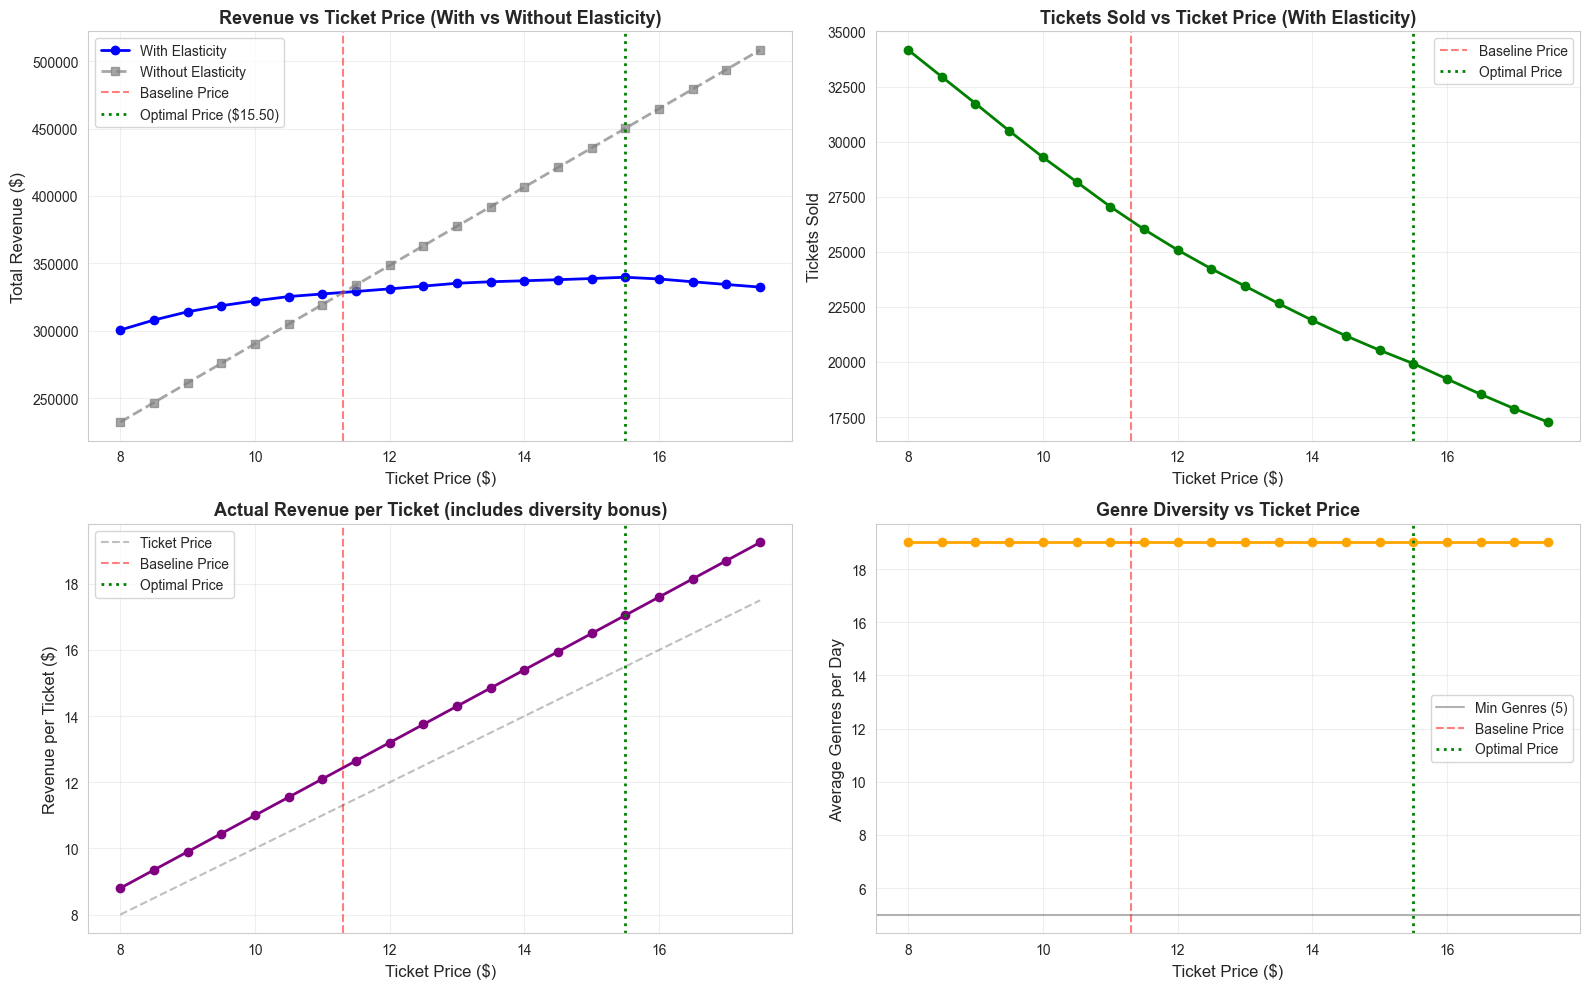


Key Findings:
  Optimal ticket price (with elasticity): $15.50
  Revenue at optimal price: $339,733.98
  Revenue at baseline price: $300,623.53
  Improvement from optimal pricing: $39,110.45


In [35]:
# Visualize ticket price sensitivity - COMPARISON
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Revenue vs Price - COMPARISON
axes[0, 0].plot(price_df['ticket_price'], price_df['revenue'], marker='o', linewidth=2, label='With Elasticity', color='blue')
axes[0, 0].plot(price_df_no_elasticity['ticket_price'], price_df_no_elasticity['revenue'], marker='s', linewidth=2, linestyle='--', label='Without Elasticity', color='gray', alpha=0.7)
axes[0, 0].axvline(BASELINE_TICKET_PRICE, color='red', linestyle='--', label='Baseline Price', alpha=0.5)
optimal_price_idx = price_df['revenue'].idxmax()
optimal_price = price_df.loc[optimal_price_idx, 'ticket_price']
axes[0, 0].axvline(optimal_price, color='green', linestyle=':', label=f'Optimal Price (${optimal_price:.2f})', linewidth=2)
axes[0, 0].set_xlabel('Ticket Price ($)', fontsize=12)
axes[0, 0].set_ylabel('Total Revenue ($)', fontsize=12)
axes[0, 0].set_title('Revenue vs Ticket Price (With vs Without Elasticity)', fontsize=13, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Tickets Sold vs Price
axes[0, 1].plot(price_df['ticket_price'], price_df['tickets'], marker='o', linewidth=2, color='green')
axes[0, 1].axvline(BASELINE_TICKET_PRICE, color='red', linestyle='--', label='Baseline Price', alpha=0.5)
axes[0, 1].axvline(optimal_price, color='green', linestyle=':', label=f'Optimal Price', linewidth=2)
axes[0, 1].set_xlabel('Ticket Price ($)', fontsize=12)
axes[0, 1].set_ylabel('Tickets Sold', fontsize=12)
axes[0, 1].set_title('Tickets Sold vs Ticket Price (With Elasticity)', fontsize=13, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Revenue per Ticket
price_df['revenue_per_ticket'] = price_df['revenue'] / price_df['tickets']
axes[1, 0].plot(price_df['ticket_price'], price_df['revenue_per_ticket'], marker='o', linewidth=2, color='purple')
axes[1, 0].plot(price_df['ticket_price'], price_df['ticket_price'], linestyle='--', color='gray', alpha=0.5, label='Ticket Price')
axes[1, 0].axvline(BASELINE_TICKET_PRICE, color='red', linestyle='--', label='Baseline Price', alpha=0.5)
axes[1, 0].axvline(optimal_price, color='green', linestyle=':', label=f'Optimal Price', linewidth=2)
axes[1, 0].set_xlabel('Ticket Price ($)', fontsize=12)
axes[1, 0].set_ylabel('Revenue per Ticket ($)', fontsize=12)
axes[1, 0].set_title('Actual Revenue per Ticket (includes diversity bonus)', fontsize=13, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Average Genres per Day
axes[1, 1].plot(price_df['ticket_price'], price_df['avg_genres'], marker='o', linewidth=2, color='orange')
axes[1, 1].axhline(MIN_GENRES, color='black', linestyle='-', alpha=0.3, label=f'Min Genres ({MIN_GENRES})')
axes[1, 1].axvline(BASELINE_TICKET_PRICE, color='red', linestyle='--', label='Baseline Price', alpha=0.5)
axes[1, 1].axvline(optimal_price, color='green', linestyle=':', label=f'Optimal Price', linewidth=2)
axes[1, 1].set_xlabel('Ticket Price ($)', fontsize=12)
axes[1, 1].set_ylabel('Average Genres per Day', fontsize=12)
axes[1, 1].set_title('Genre Diversity vs Ticket Price', fontsize=13, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(results_dir / 'sensitivity_ticket_price_enhanced.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nKey Findings:")
print(f"  Optimal ticket price (with elasticity): ${optimal_price:.2f}")
print(f"  Revenue at optimal price: ${price_df.loc[optimal_price_idx, 'revenue']:,.2f}")
print(f"  Revenue at baseline price: ${price_df[price_df['ticket_price'] <= BASELINE_TICKET_PRICE+ 1]['revenue'].values[0]:,.2f}")
print(f"  Improvement from optimal pricing: ${price_df.loc[optimal_price_idx, 'revenue'] - price_df[price_df['ticket_price'] <= BASELINE_TICKET_PRICE+ 1]['revenue'].values[0]:,.2f}")